In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from data_pipeline import DataPipeline, load_data, train_test_split


## Task A1: EDA khảo sát và chẩn đoán


In [28]:
data_path = Path("data/melb_data.csv")
df = load_data(data_path)
df.head()


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

Schema xác nhận `Price` là target, dữ liệu gồm numeric và categorical;

In [30]:
df.describe()


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [31]:
numeric_raw_columns = df.select_dtypes(include=np.number).columns.tolist()
raw_descriptive_stats = pd.DataFrame(
    {
        "mean": df[numeric_raw_columns].mean(),
        "median": df[numeric_raw_columns].median(),
        "std": df[numeric_raw_columns].std(),
        "min": df[numeric_raw_columns].min(),
        "q1": df[numeric_raw_columns].quantile(0.25),
        "q2": df[numeric_raw_columns].quantile(0.50),
        "q3": df[numeric_raw_columns].quantile(0.75),
        "max": df[numeric_raw_columns].max(),
    }
).round(2)
raw_descriptive_stats


,mean,median,std,min,q1,q2,q3,max
Rooms,2.94,3.0,0.96,1.00,2.00,3.0,3.00,10.00
Price,1075684.08,903000.0,639310.72,85000.00,650000.00,903000.0,1330000.00,9000000.00
Distance,10.14,9.2,5.87,0.00,6.10,9.2,13.00,48.10
Postcode,3105.30,3084.0,90.68,3000.00,3044.00,3084.0,3148.00,3977.00
Bedroom2,2.91,3.0,0.97,0.00,2.00,3.0,3.00,20.00
Bathroom,1.53,1.0,0.69,0.00,1.00,1.0,2.00,8.00
Car,1.61,2.0,0.96,0.00,1.00,2.0,2.00,10.00
Landsize,558.42,440.0,3990.67,0.00,177.00,440.0,651.00,433014.00
BuildingArea,151.97,126.0,541.01,0.00,93.00,126.0,174.00,44515.00
YearBuilt,1964.68,1970.0,37.27,1196.00,1940.00,1970.0,1999.00,2018.00


Bảng thống kê raw dùng để nhìn biên độ và độ lệch giữa mean/median.


In [32]:
duplicate_rows = int(df.duplicated().sum())
duplicate_check = pd.DataFrame(
    {
        "metric": ["duplicate_rows", "duplicate_pct"],
        "value": [duplicate_rows, round(duplicate_rows / len(df) * 100, 2)],
    }
)
duplicate_check


,metric,value
0,duplicate_rows,0.0
1,duplicate_pct,0.0


Duplicate check chỉ kiểm tra dòng trùng hoàn toàn trên raw dataset; pipeline baseline không drop row ở bước EDA.


## Task A2: Chia tách dữ liệu thô


In [33]:
X_train_raw, X_test_raw = train_test_split(df, test_size=0.3, random_state=42)

split_summary = pd.DataFrame(
    {
        "split": ["X_train_raw", "X_test_raw"],
        "rows": [len(X_train_raw), len(X_test_raw)],
        "pct": [round(len(X_train_raw) / len(df) * 100, 2), round(len(X_test_raw) / len(df) * 100, 2)],
    }
)
split_summary


,split,rows,pct
0,X_train_raw,9506,70.0
1,X_test_raw,4074,30.0


Split được thực hiện trên DataFrame thô. Các thống kê dùng để chọn preprocessing chính thức lấy từ `X_train_raw`.


## EDA trên train split


In [34]:
target_distribution_check = pd.DataFrame(
    {
        "X_train_raw": X_train_raw["Price"].describe(percentiles=[0.05, 0.5, 0.95]),
        "X_test_raw": X_test_raw["Price"].describe(percentiles=[0.05, 0.5, 0.95]),
    }
).round(2)
target_distribution_check


,X_train_raw,X_test_raw
count,9506.00,4074.00
mean,1076128.42,1074647.30
std,637183.57,644324.13
min,131000.00,85000.00
5%,407125.00,400000.00
50%,905000.00,900250.00
95%,2300000.00,2261750.00
max,8000000.00,9000000.00


`Price` không thiếu giá trị và được giữ raw cho handoff; không log-transform hoặc clipping target trong phần Data Engineer.


In [35]:
train_missing_summary = pd.DataFrame(
    {
        "missing_count": X_train_raw.isna().sum(),
        "missing_pct": X_train_raw.isna().mean().mul(100).round(2),
    }
).query("missing_count > 0").sort_values("missing_pct", ascending=False)
train_missing_summary


,missing_count,missing_pct
BuildingArea,4557,47.94
YearBuilt,3815,40.13
CouncilArea,953,10.03
Car,42,0.44


`BuildingArea` và `YearBuilt` thiếu nhiều nhất, nên dùng median train-only thay vì mean để giảm ảnh hưởng của phân phối lệch và outlier.


In [36]:
train_invalid_summary = pd.DataFrame(
    [
        {"check": "Price <= 0", "rows": int((X_train_raw["Price"] <= 0).sum())},
        {"check": "Rooms == 0", "rows": int((X_train_raw["Rooms"] == 0).sum())},
        {"check": "Landsize <= 0", "rows": int((X_train_raw["Landsize"] <= 0).sum())},
        {"check": "BuildingArea <= 0", "rows": int((X_train_raw["BuildingArea"] <= 0).sum())},
        {"check": "YearBuilt < 1800", "rows": int((X_train_raw["YearBuilt"] < 1800).sum())},
    ]
)
train_invalid_summary


,check,rows
0,Price <= 0,0
1,Rooms == 0,0
2,Landsize <= 0,1353
3,BuildingArea <= 0,13
4,YearBuilt < 1800,1


Các điều kiện invalid này có ý nghĩa theo miền dữ liệu nên được repair trong pipeline; outlier giá trị lớn không bị drop tự động.


In [37]:
outlier_columns = ["Price", "Landsize", "BuildingArea", "YearBuilt"]
train_outlier_quantiles = X_train_raw[outlier_columns].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).T.round(2)
train_outlier_quantiles


,0.01,0.05,0.50,0.95,0.99
Price,300050.00,407125.0,905000.0,2300000.0,3359500.00
Landsize,0.00,0.0,446.0,1002.5,2976.85
BuildingArea,6.92,52.4,126.0,291.0,446.60
YearBuilt,1880.00,1900.0,1970.0,2012.0,2015.00


In [38]:
iqr_rows = []
for column in outlier_columns:
    series = X_train_raw[column].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((series < lower_bound) | (series > upper_bound)).sum())
    iqr_rows.append(
        {
            "column": column,
            "iqr_outliers": outlier_count,
            "outlier_pct_iqr": round(outlier_count / len(series) * 100, 2),
            "iqr_lower_bound": round(lower_bound, 2),
            "iqr_upper_bound": round(upper_bound, 2),
        }
    )

train_iqr_outlier_summary = pd.DataFrame(iqr_rows).sort_values("outlier_pct_iqr", ascending=False)
train_iqr_outlier_summary


,column,iqr_outliers,outlier_pct_iqr,iqr_lower_bound,iqr_upper_bound
2,BuildingArea,244,4.93,-28.0,292.0
0,Price,442,4.65,-370000.0,2350000.0
1,Landsize,269,2.83,-529.0,1359.0
3,YearBuilt,6,0.11,1851.5,2087.5


Quantile và IQR tập trung vào `Price`, `Landsize`, `BuildingArea`, `YearBuilt` vì đây là các biến ảnh hưởng trực tiếp tới imputation, scaling và feature engineering. Không dùng z-score vì các biến này lệch phải mạnh.


In [39]:
numeric_columns = [
    "Price",
    "Rooms",
    "Bedroom2",
    "Bathroom",
    "Car",
    "Distance",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Propertycount",
]

numeric_profile = X_train_raw[numeric_columns].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
numeric_profile["skew"] = X_train_raw[numeric_columns].skew(numeric_only=True)
numeric_profile.round(2)


,count,mean,std,min,1%,5%,50%,95%,99%,max,skew
Price,9506.0,1076128.42,637183.57,131000.0,300050.00,407125.0,905000.0,2300000.0,3359500.00,8000000.0,2.19
Rooms,9506.0,2.94,0.95,1.0,1.00,2.0,3.0,4.0,5.00,10.0,0.35
Bedroom2,9506.0,2.93,0.97,0.0,1.00,1.0,3.0,4.0,5.00,20.0,0.92
Bathroom,9506.0,1.53,0.69,0.0,1.00,1.0,1.0,3.0,3.95,8.0,1.32
Car,9464.0,1.60,0.95,0.0,0.00,0.0,2.0,3.0,4.00,10.0,1.34
Distance,9506.0,10.12,5.90,0.0,1.60,2.6,9.2,20.6,32.27,48.1,1.67
Landsize,9506.0,541.64,1642.07,0.0,0.00,0.0,446.0,1002.5,2976.85,76000.0,28.97
BuildingArea,4949.0,154.42,646.59,0.0,6.92,52.4,126.0,291.0,446.60,44515.0,65.56
YearBuilt,5691.0,1964.41,37.74,1196.0,1880.00,1900.0,1970.0,2012.0,2015.00,2018.0,-1.94
Propertycount,9506.0,7490.50,4385.61,249.0,962.00,2211.0,6567.0,14949.0,21650.00,21650.0,1.08


`Landsize`, `BuildingArea`, `Distance` có scale lệch mạnh so với biến đếm; scaling sau preprocessing giúp ma trận OLS ổn định hơn.


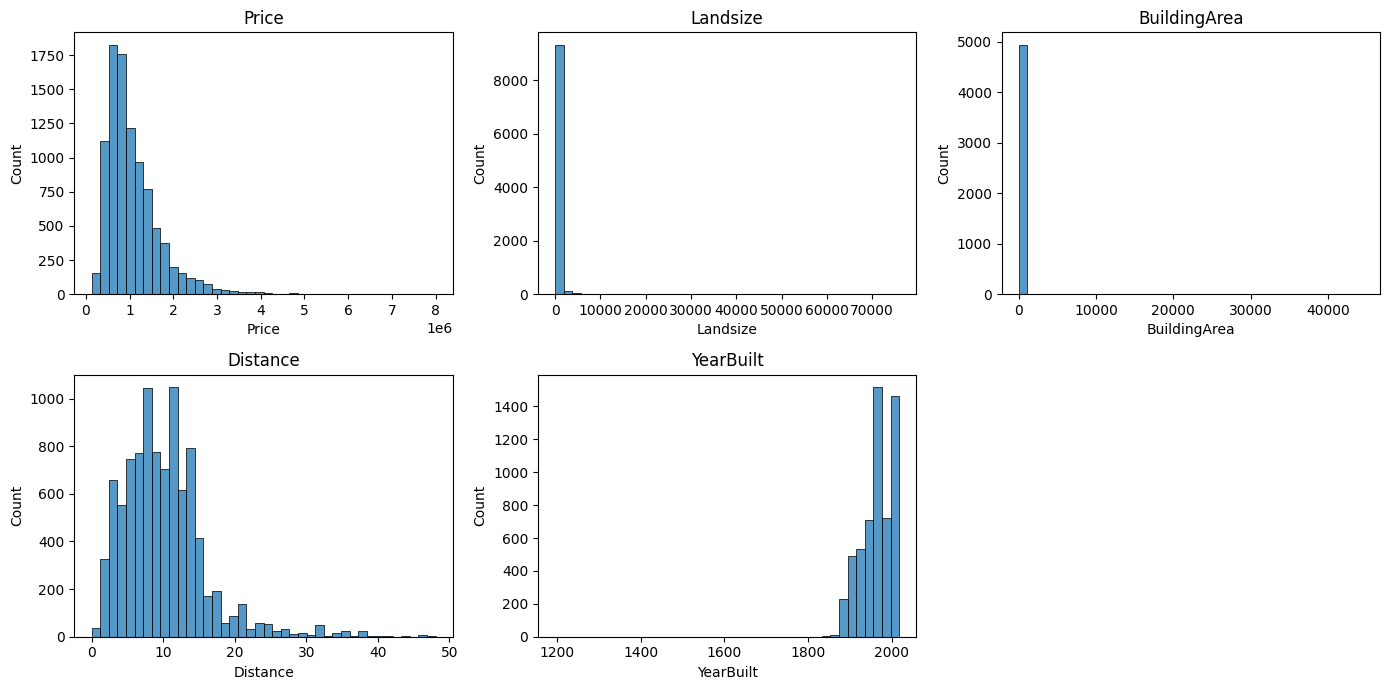

In [40]:
plot_columns = ["Price", "Landsize", "BuildingArea", "Distance", "YearBuilt"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, plot_columns):
    sns.histplot(data=X_train_raw, x=column, bins=40, ax=ax)
    ax.set_title(column)

for ax in axes[len(plot_columns):]:
    ax.set_visible(False)

plt.tight_layout()


`Price`, `Landsize`, `BuildingArea` lệch phải nên các bước fill và fallback ưu tiên median.


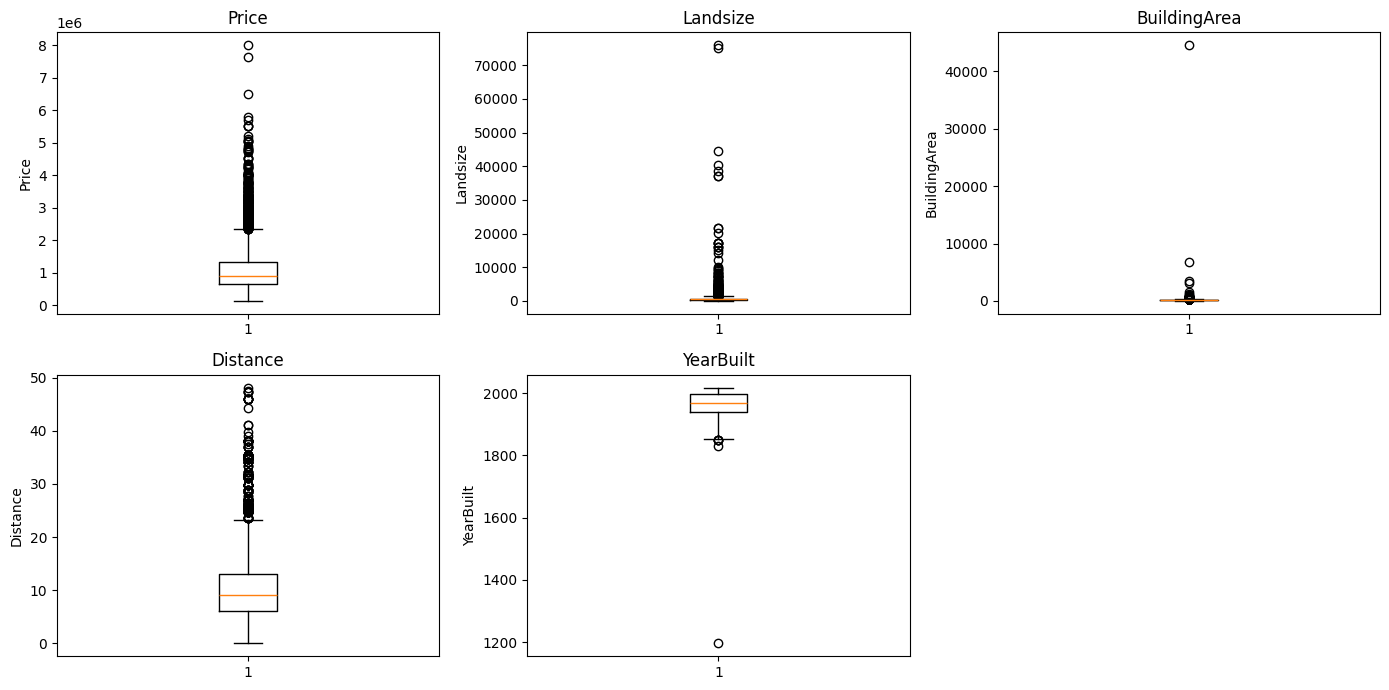

In [41]:
plot_columns = ["Price", "Landsize", "BuildingArea", "Distance", "YearBuilt"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, column in zip(axes, plot_columns):
    ax.boxplot(X_train_raw[column].dropna(), vert=True)
    ax.set_title(column)
    ax.set_ylabel(column)

for ax in axes[len(plot_columns):]:
    ax.set_visible(False)

plt.tight_layout()


Boxplot dùng để nhận diện đuôi dài và điểm cực trị của các biến chính; pipeline chỉ repair invalid values, không loại bỏ nhà giá cao hoặc đất lớn hợp lệ.


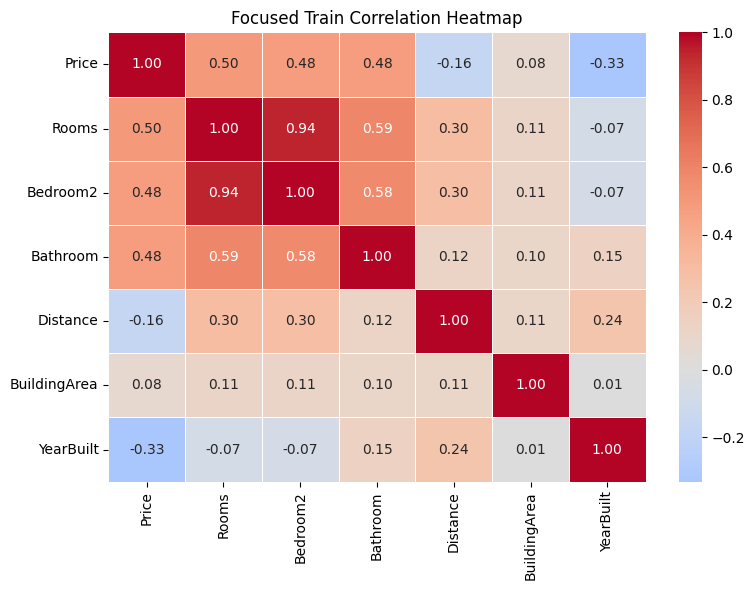

In [42]:
corr_columns = ["Price", "Rooms", "Bedroom2", "Bathroom", "Distance", "BuildingArea", "YearBuilt"]
focused_corr = X_train_raw[corr_columns].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(focused_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Focused Train Correlation Heatmap")
plt.tight_layout()


Heatmap tập trung vào các biến có rủi ro đa cộng tuyến hoặc liên quan trực tiếp tới `Price`. `Bedroom2` chồng lấp với `Rooms`, còn `YearBuilt` được chuyển thành `Age` rồi drop trong pipeline.


In [43]:
relationship_columns = ["Price", "Rooms", "Bedroom2", "Bathroom", "Car", "Distance", "BuildingArea", "YearBuilt"]
relationship_summary = X_train_raw[relationship_columns].corr(numeric_only=True)[["Price", "Rooms"]].round(3)
relationship_summary


,Price,Rooms
Price,1.000,0.499
Rooms,0.499,1.000
Bedroom2,0.480,0.941
Bathroom,0.481,0.593
Car,0.238,0.402
Distance,-0.164,0.298
BuildingArea,0.079,0.112
YearBuilt,-0.331,-0.075


Bảng tương quan nhỏ giữ lại phần số cụ thể cho quyết định drop `Bedroom2` và không tạo `OtherRooms`, tránh phụ thuộc tuyến tính không cần thiết cho OLS.


In [44]:
categorical_columns = ["Type", "Regionname", "Method", "CouncilArea"]
categorical_summary = pd.DataFrame(
    {
        "column": categorical_columns,
        "unique_values": [X_train_raw[column].nunique(dropna=True) for column in categorical_columns],
        "missing_pct": [round(X_train_raw[column].isna().mean() * 100, 2) for column in categorical_columns],
        "top_value": [X_train_raw[column].mode(dropna=True).iloc[0] for column in categorical_columns],
    }
)
categorical_summary


,column,unique_values,missing_pct,top_value
0,Type,3,0.00,h
1,Regionname,8,0.00,Southern Metropolitan
2,Method,5,0.00,S
3,CouncilArea,33,10.03,Moreland


In [45]:
type_price = X_train_raw.groupby("Type")["Price"].agg(["count", "median", "mean"]).round(0)
region_price = (
    X_train_raw.groupby("Regionname")["Price"]
    .agg(["count", "median"])
    .sort_values("median", ascending=False)
    .round(0)
)

type_price, region_price


(      count     median       mean
 Type                             
 h      6614  1080500.0  1243525.0
 t       767   841000.0   928520.0
 u      2125   565000.0   608391.0,
                             count     median
 Regionname                                  
 Southern Metropolitan        3280  1250000.0
 Eastern Metropolitan         1035  1005000.0
 South-Eastern Metropolitan    314   850000.0
 Northern Metropolitan        2771   810000.0
 Western Metropolitan         2012   799000.0
 Eastern Victoria               38   653000.0
 Northern Victoria              32   537500.0
 Western Victoria               24   400000.0)

Với baseline OLS, `Type` và `Regionname` đủ gọn để one-hot mà vẫn giữ tín hiệu loại nhà và khu vực. Bảng median price theo nhóm giải thích vì sao hai cột này được giữ.


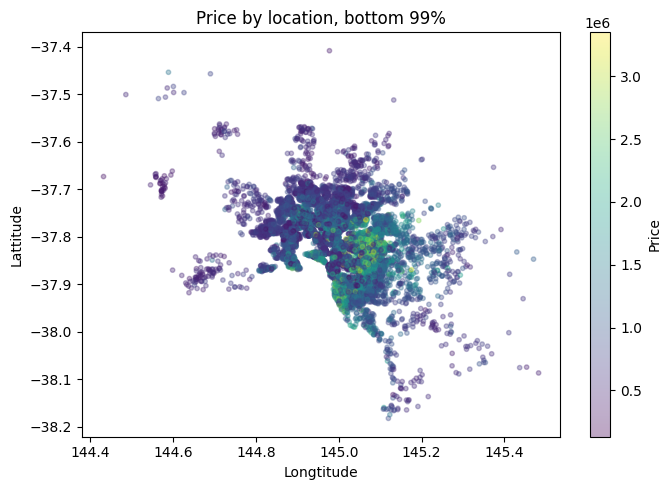

In [46]:
geo_df = X_train_raw[X_train_raw["Price"] < X_train_raw["Price"].quantile(0.99)]
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    geo_df["Longtitude"],
    geo_df["Lattitude"],
    c=geo_df["Price"],
    alpha=0.35,
    s=10,
)
plt.xlabel("Longtitude")
plt.ylabel("Lattitude")
plt.title("Price by location, bottom 99%")
plt.colorbar(scatter, label="Price")
plt.tight_layout()


Geo scatter chứng minh `Lattitude` và `Longtitude` có tín hiệu không gian rõ. Lọc bottom 99% chỉ để nhìn plot dễ hơn, không thay đổi dữ liệu pipeline.


In [47]:
feature_preview = X_train_raw[["Rooms", "BuildingArea", "Landsize", "YearBuilt", "Date"]].copy()
feature_preview["SaleYear"] = pd.to_datetime(feature_preview["Date"], dayfirst=True, errors="coerce").dt.year
feature_preview["Age"] = feature_preview["SaleYear"] - feature_preview["YearBuilt"]
feature_preview["BuildingArea_per_Room"] = feature_preview["BuildingArea"] / feature_preview["Rooms"].replace(0, np.nan)
feature_preview["BuildingCoverage"] = feature_preview["BuildingArea"] / feature_preview["Landsize"].replace(0, np.nan)
feature_preview[["Age", "BuildingArea_per_Room", "BuildingCoverage"]].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Age,5691.0,52.08,37.69,-2.0,18.00,47.00,76.00,821.0
BuildingArea_per_Room,4949.0,50.03,132.68,0.0,37.33,44.00,53.00,8903.0
BuildingCoverage,4214.0,0.44,1.21,0.0,0.22,0.34,0.54,62.0


`Age` dùng năm bán từ `Date`, không dùng mốc năm hiện tại. Ratio features giữ ở mức đơn giản và được fallback bằng median train nếu phát sinh NaN/inf.


## Tasks A3-A6: Thực thi pipeline


In [48]:
pipeline = DataPipeline(drop_columns=["BuildingArea_per_Room", "Bedroom2"])
X_train, y_train = pipeline.fit_transform(X_train_raw)
X_test, y_test = pipeline.transform(X_test_raw)

metadata = {
    "feature_names": pipeline.feature_names,
    "target_name": pipeline.target_name,
    "drop_columns": pipeline.drop_columns,
    "engineered_features": [
        "Age",
        "BuildingCoverage",
        "BuildingArea_missing",
        "YearBuilt_missing",
        "Landsize_zero_or_missing",
    ],
    "encoding_strategy": "one_hot_drop_first",
    "imputation_strategy": "MV2_column_median_train_only",
    "scaling_method": "standardize",
}

pd.DataFrame(
    {
        "artifact": ["X_train", "X_test", "y_train", "y_test", "features"],
        "shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape, len(metadata["feature_names"])],
    }
)


,artifact,shape
0,X_train,"(9506, 23)"
1,X_test,"(4074, 23)"
2,y_train,"(9506,)"
3,y_test,"(4074,)"
4,features,23


## Feature contract validation


In [49]:
expected_engineered_features = metadata["engineered_features"]
X_train_df = pd.DataFrame(X_train, columns=metadata["feature_names"])
X_test_df = pd.DataFrame(X_test, columns=metadata["feature_names"])

feature_contract_check = pd.DataFrame(
    {
        "feature": expected_engineered_features,
        "exists_in_output": [feature in metadata["feature_names"] for feature in expected_engineered_features],
        "train_has_no_nan": [
            bool(not X_train_df[feature].isna().any()) if feature in X_train_df.columns else False
            for feature in expected_engineered_features
        ],
        "test_has_no_nan": [
            bool(not X_test_df[feature].isna().any()) if feature in X_test_df.columns else False
            for feature in expected_engineered_features
        ],
        "train_is_finite": [
            bool(np.isfinite(X_train_df[feature]).all()) if feature in X_train_df.columns else False
            for feature in expected_engineered_features
        ],
        "test_is_finite": [
            bool(np.isfinite(X_test_df[feature]).all()) if feature in X_test_df.columns else False
            for feature in expected_engineered_features
        ],
    }
)

failed_feature_contract = feature_contract_check.loc[
    ~feature_contract_check.drop(columns=["feature"]).all(axis=1)
]
assert failed_feature_contract.empty, failed_feature_contract.to_string(index=False)
feature_contract_check


,feature,exists_in_output,train_has_no_nan,test_has_no_nan,train_is_finite,test_is_finite
0,Age,True,True,True,True,True
1,BuildingCoverage,True,True,True,True,True
2,BuildingArea_missing,True,True,True,True,True
3,YearBuilt_missing,True,True,True,True,True
4,Landsize_zero_or_missing,True,True,True,True,True


## OLS matrix rank check


In [50]:
X_design = np.c_[np.ones(X_train.shape[0]), X_train]
design_rank = np.linalg.matrix_rank(X_design)
condition_number = np.linalg.cond(X_design)

rank_check = pd.DataFrame(
    {
        "metric": ["n_columns", "matrix_rank", "full_rank", "condition_number"],
        "value": [
            X_design.shape[1],
            design_rank,
            bool(design_rank == X_design.shape[1]),
            float(condition_number),
        ],
    }
)

assert design_rank == X_design.shape[1]
assert condition_number < 1e10
rank_check


,metric,value
0,n_columns,24
1,matrix_rank,24
2,full_rank,True
3,condition_number,6.758866


Condition number giúp phát hiện ma trận gần suy biến.


## Handoff validation


In [51]:
handoff_checks = pd.DataFrame(
    [
        {"check": "X_train has no NaN", "passed": bool(not np.isnan(X_train).any())},
        {"check": "X_test has no NaN", "passed": bool(not np.isnan(X_test).any())},
        {"check": "X_train is finite", "passed": bool(np.isfinite(X_train).all())},
        {"check": "X_test is finite", "passed": bool(np.isfinite(X_test).all())},
        {"check": "same feature count", "passed": bool(X_train.shape[1] == X_test.shape[1])},
        {"check": "metadata feature count", "passed": bool(len(metadata["feature_names"]) == X_train.shape[1])},
        {"check": "y_train has no NaN", "passed": bool(not np.isnan(y_train).any())},
        {"check": "y_test has no NaN", "passed": bool(not np.isnan(y_test).any())},
        {"check": "y_train is finite", "passed": bool(np.isfinite(y_train).all())},
        {"check": "y_test is finite", "passed": bool(np.isfinite(y_test).all())},
        {"check": "y_train is positive", "passed": bool((y_train > 0).all())},
        {"check": "y_test is positive", "passed": bool((y_test > 0).all())},
        {"check": "X_train/y_train aligned", "passed": bool(X_train.shape[0] == len(y_train))},
        {"check": "X_test/y_test aligned", "passed": bool(X_test.shape[0] == len(y_test))},
    ]
)

assert handoff_checks["passed"].all()
handoff_checks


,check,passed
0,X_train has no NaN,True
1,X_test has no NaN,True
2,X_train is finite,True
3,X_test is finite,True
4,same feature count,True
5,metadata feature count,True
6,y_train has no NaN,True
7,y_test has no NaN,True
8,y_train is finite,True
9,y_test is finite,True


In [52]:
pd.DataFrame({"feature_name": metadata["feature_names"]})


,feature_name
0,Rooms
1,Distance
2,Bathroom
3,Car
4,Landsize
5,BuildingArea
6,Lattitude
7,Longtitude
8,Propertycount
9,BuildingArea_missing
